In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest
from sklearn.ensemble import RandomForestClassifier
from fpdf import FPDF
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import root_mean_squared_error
from sklearn.metrics import accuracy_score

In [2]:
rawData = pd.read_csv('raw_dataset.csv')
rawData.columns = rawData.columns.str.strip().str.replace(' ', '_')
print(rawData.head().to_string(index=False))
print(rawData.shape)

 Customer_ID  Age Gender   Income  Spending_Score  Credit_Score  Loan_Amount  Previous_Defaults  Marketing_Spend  Purchase_Frequency Seasonality  Sales  Customer_Churn  Defaulted
           1   56 Female 142418.0               7         391.0       8083.0                  1            15376                   3         Low  32526               0          0
           2   69   Male  63088.0              82         652.0      34328.0                  2             6889                   6         Low  78493               0          0
           3   46   Male 136868.0              91         662.0      47891.0                  2             6054                  29      Medium  57198               1          0
           4   32 Female      NaN              34         644.0      25103.0                  2             4868                   8      Medium  48395               0          0
           5   60   Male  59811.0              91         469.0      44891.0                  1          

In [3]:
# Check column names and data types
print(rawData.info())

# Check summary statistics
print(rawData.describe(include='all'))

# Check for missing values
print(rawData.isnull().sum())



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Customer_ID         500 non-null    int64  
 1   Age                 500 non-null    int64  
 2   Gender              500 non-null    object 
 3   Income              450 non-null    float64
 4   Spending_Score      500 non-null    int64  
 5   Credit_Score        450 non-null    float64
 6   Loan_Amount         450 non-null    float64
 7   Previous_Defaults   500 non-null    int64  
 8   Marketing_Spend     500 non-null    int64  
 9   Purchase_Frequency  500 non-null    int64  
 10  Seasonality         500 non-null    object 
 11  Sales               500 non-null    int64  
 12  Customer_Churn      500 non-null    int64  
 13  Defaulted           500 non-null    int64  
dtypes: float64(3), int64(9), object(2)
memory usage: 54.8+ KB
None
        Customer_ID         Age Gender     

In [4]:
print(rawData['Defaulted'].value_counts(dropna=False))

Defaulted
0    405
1     95
Name: count, dtype: int64


In [5]:
# Separate binary columns
binary_cols = ['Customer_Churn', 'Defaulted']
numerical_cols = [col for col in rawData.select_dtypes(include=['float64', 'int64']).columns if col not in binary_cols]
numerical_cols = [col for col in numerical_cols if col not in binary_cols]

# Fill missing values
rawData[numerical_cols] = rawData[numerical_cols].fillna(rawData[numerical_cols].mean())
for col in binary_cols:
    rawData[col] = rawData[col].fillna(rawData[col].mode()[0]).astype(int)

# Fill categorical columns
categorical_cols = rawData.select_dtypes(include=['object']).columns
for col in categorical_cols:
    rawData[col] = rawData[col].fillna(rawData[col].mode()[0])

# Remove duplicates
rawData = rawData.drop_duplicates()

# Remove outliers
for col in numerical_cols:
    Q1 = rawData[col].quantile(0.25)
    Q3 = rawData[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    rawData = rawData[(rawData[col] >= lower_bound) & (rawData[col] <= upper_bound)]

print("After cleaning:", rawData['Defaulted'].value_counts())

# Save cleaned data
rawData.to_csv('cleaned_dataset.csv', index=False)


After cleaning: Defaulted
0    405
1     95
Name: count, dtype: int64


In [7]:
cleanedData = pd.read_csv('cleaned_dataset.csv')
print(cleanedData.head().to_string(index=False))
print(cleanedData.shape)

 Customer_ID  Age Gender        Income  Spending_Score  Credit_Score  Loan_Amount  Previous_Defaults  Marketing_Spend  Purchase_Frequency Seasonality  Sales  Customer_Churn  Defaulted
           1   56 Female 142418.000000               7         391.0       8083.0                  1            15376                   3         Low  32526               0          0
           2   69   Male  63088.000000              82         652.0      34328.0                  2             6889                   6         Low  78493               0          0
           3   46   Male 136868.000000              91         662.0      47891.0                  2             6054                  29      Medium  57198               1          0
           4   32 Female  84398.055556              34         644.0      25103.0                  2             4868                   8      Medium  48395               0          0
           5   60   Male  59811.000000              91         469.0      44891.

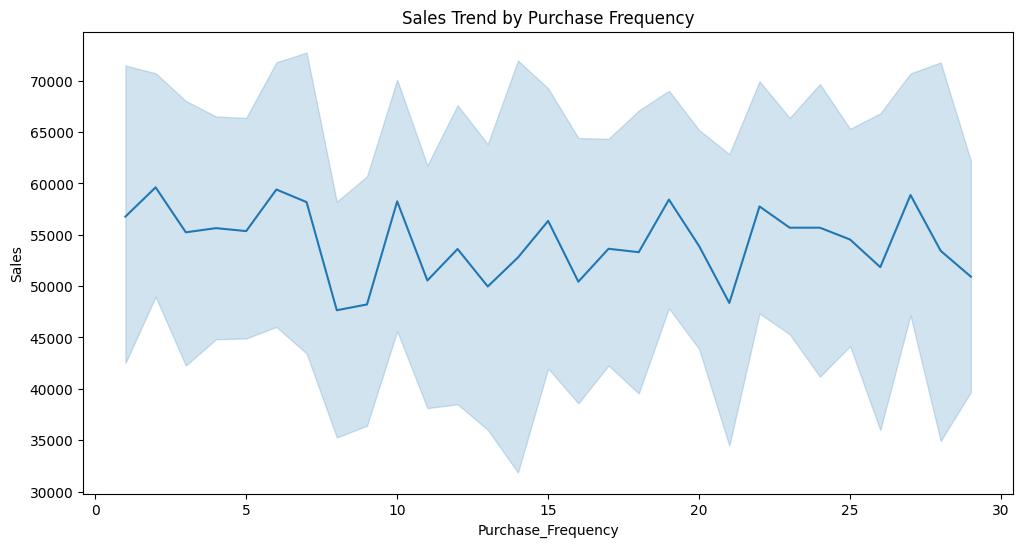

In [9]:
# Trends over time
plt.figure(figsize=(12, 6))

sns.lineplot(data=cleanedData, x="Purchase_Frequency", y="Sales")
plt.title("Sales Trend by Purchase Frequency")
plt.savefig("sales_trend.png", bbox_inches='tight')
plt.show()

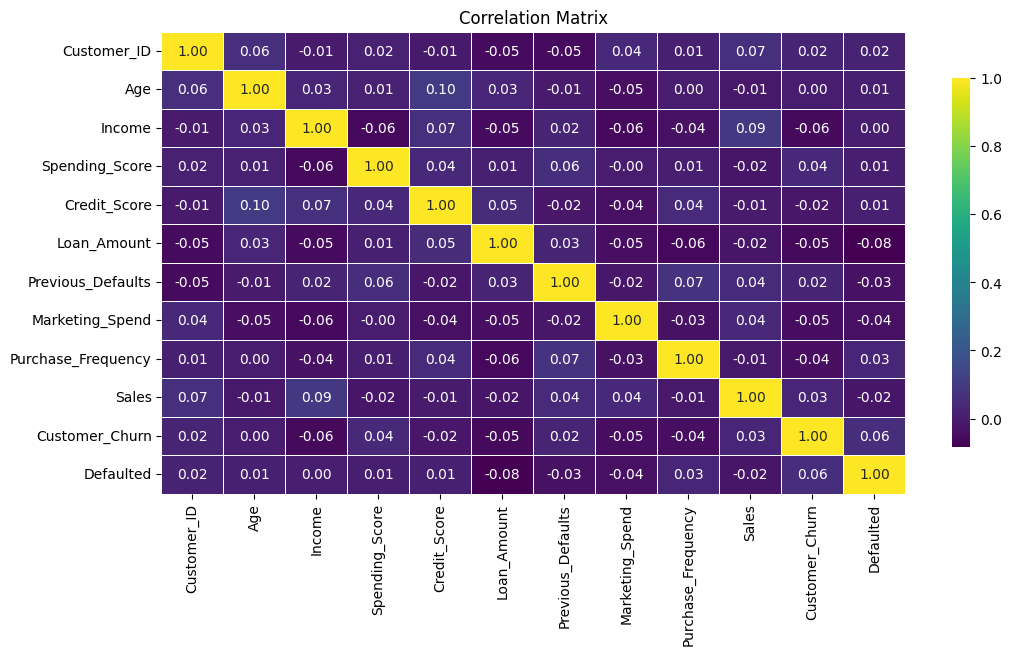

In [85]:
# Correlations Between Variables
plt.figure(figsize=(12, 6))

# Correlation heatmap
corr = cleanedData.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap="viridis", fmt=".2f", linewidths=0.5, cbar_kws={"shrink": .8})
plt.title("Correlation Matrix")
plt.show()


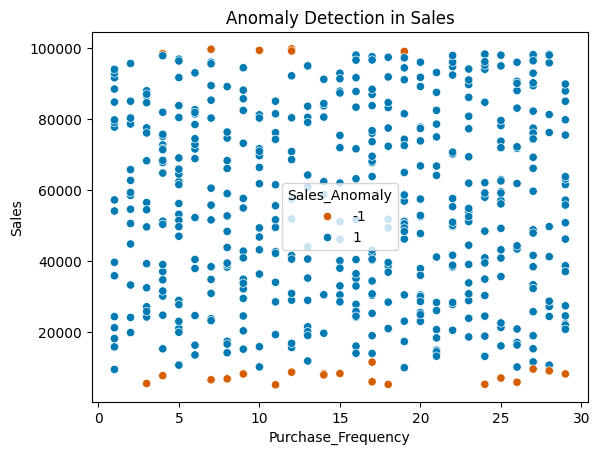

In [86]:
# Use AI Features for Deeper Insights
# Anomaly Detection (using Isolation Forest)

# Fit model on Sales
model = IsolationForest(contamination=0.05)
cleanedData["Sales_Anomaly"] = model.fit_predict(cleanedData[["Sales"]])

# Visualize anomalies
sns.scatterplot(data=cleanedData, x="Purchase_Frequency", y="Sales", hue="Sales_Anomaly", palette={1: "#007AB2", -1: "#D55E00"})
plt.title("Anomaly Detection in Sales")
plt.show()



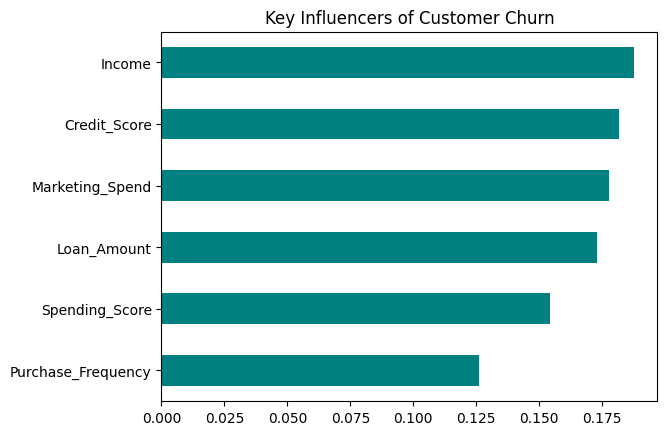

In [87]:
# Key Influencers (Feature Importance for Churn)

# Prepare data
features = ["Income", "Spending_Score", "Credit_Score", "Loan_Amount", "Marketing_Spend", "Purchase_Frequency"]
customer_features = cleanedData[features]
churn_labels = cleanedData["Customer_Churn"]

# Train model
model = RandomForestClassifier()
model.fit(customer_features, churn_labels)

# Feature importance
importances = pd.Series(model.feature_importances_, index=features)
importances.sort_values().plot(kind="barh", color="#008080")
plt.title("Key Influencers of Customer Churn")
plt.show()


In [101]:
#  Smart Narratives:

narrative = f"""
Summary of Insights:
- Average Sales: £{cleanedData['Sales'].mean():,.2f}
- Top Correlated Features with Sales: {corr['Sales'].sort_values(ascending=False)[1:4].index.tolist()}
- Anomalies Detected: {cleanedData[cleanedData['Sales_Anomaly'] == -1].shape[0]} unusual sales records.
- Key Drivers of Churn: {importances.sort_values(ascending=False).head(3).index.tolist()}
"""
print(narrative )



Summary of Insights:
- Average Sales: £54,378.95
- Top Correlated Features with Sales: ['Income', 'Customer_ID', 'Previous_Defaults']
- Anomalies Detected: 25 unusual sales records.
- Key Drivers of Churn: ['Income', 'Credit_Score', 'Marketing_Spend']



In [102]:
pdf = FPDF()
pdf.add_page()
pdf.set_font("Arial", size=12)

for line in narrative.split("\n"):
    pdf.multi_cell(0, 10, line)

pdf.output("Smart_Narrative_Report.pdf")

''

In [ ]:
# AI-Driven Predictive and Prescriptive Analytics
target = 'Sales'
features = cleanedData.drop(columns=[target])

# Encode categorical columns
df_encoded = pd.get_dummies(cleanedData)

# Split into features and target
X = df_encoded.drop(columns=[target])
y = df_encoded[target]

# Train the Model
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestRegressor()
model.fit(X_train, y_train)
predictions = model.predict(X_test)

rmse = root_mean_squared_error(y_test, predictions)
print("RMSE:", rmse)
print("Average Sales:", cleanedData["Sales"].mean())


RMSE: 29151.12517384907
Average Sales: 54378.954


In [113]:
#  AI for Business Strategy and Risk Management

# Check class balance
print(cleanedData["Defaulted"].value_counts()) 

# Inspect data types and nulls 
print(cleanedData.info())  


Defaulted
0    405
1     95
Name: count, dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Customer_ID         500 non-null    int64  
 1   Age                 500 non-null    int64  
 2   Gender              500 non-null    object 
 3   Income              500 non-null    float64
 4   Spending_Score      500 non-null    int64  
 5   Credit_Score        500 non-null    float64
 6   Loan_Amount         500 non-null    float64
 7   Previous_Defaults   500 non-null    int64  
 8   Marketing_Spend     500 non-null    int64  
 9   Purchase_Frequency  500 non-null    int64  
 10  Seasonality         500 non-null    object 
 11  Sales               500 non-null    int64  
 12  Customer_Churn      500 non-null    int64  
 13  Defaulted           500 non-null    int64  
 14  Sales_Anomaly       500 non-null    int64  
dtypes: 

In [ ]:
#  AI for Business Strategy and Risk Management

# Finding categorical columns
print(cleanedData.select_dtypes(include=["object"]).columns.tolist())

# Encoding categorical variables
encodedData = pd.get_dummies(cleanedData, drop_first=True)

# Define features and target
features = encodedData.drop("Defaulted", axis=1)
target_defaulted = encodedData["Defaulted"]

# Train-test split

# Split data
train_features, test_features, train_labels, test_labels = train_test_split(
    features, target_defaulted, test_size=0.2, random_state=42
)

# Train model
default_model_rf = RandomForestClassifier(random_state=42)
default_model_rf.fit(train_features, train_labels)

# Predict
default_predictions = default_model_rf.predict(test_features)

# Evaluate
print("Accuracy:", accuracy_score(test_labels, default_predictions))



['Gender', 'Seasonality']
Accuracy: 0.83
